# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## 1.2 Функции

In [113]:
def visualize_price_predictions(results_df):
    # Сортируем по дате
    results_df = results_df.sort_values('begin')
    results_df['begin'] = pd.to_datetime(results_df['begin'])

    # Вычисляем будущие даты
    results_df['future_date'] = results_df['begin'] + pd.Timedelta(days=0)
    
    # Конвертируем изменения в цены
    # Формула: future_price = current_price * (1 + price_change / 100)
    results_df['actual_future_price'] = results_df['close'] * (1 + results_df['target_price_change'] / 100)
    results_df['predicted_future_price'] = results_df['close'] * (1 + results_df['predict'] / 100)
    #display(results_df)
    
    # Создаем график
    plt.figure(figsize=(32, 8))
    plt.plot(results_df['begin'], results_df['actual_future_price'], 
             linewidth=3, color='#2E8B57', label='Реальная цена (через 7 дней)', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['future_date'], results_df['predicted_future_price'], 
             linewidth=3, color='#DC143C', label='Предсказанная цена (через 7 дней)', marker='s', markersize=4, alpha=0.8)
    
    # Настройки графика
    plt.title('Сравнение текущих, реальных и предсказанных цен акций', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Цена (₽)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Красивое оформление
    plt.tight_layout()
    plt.show()


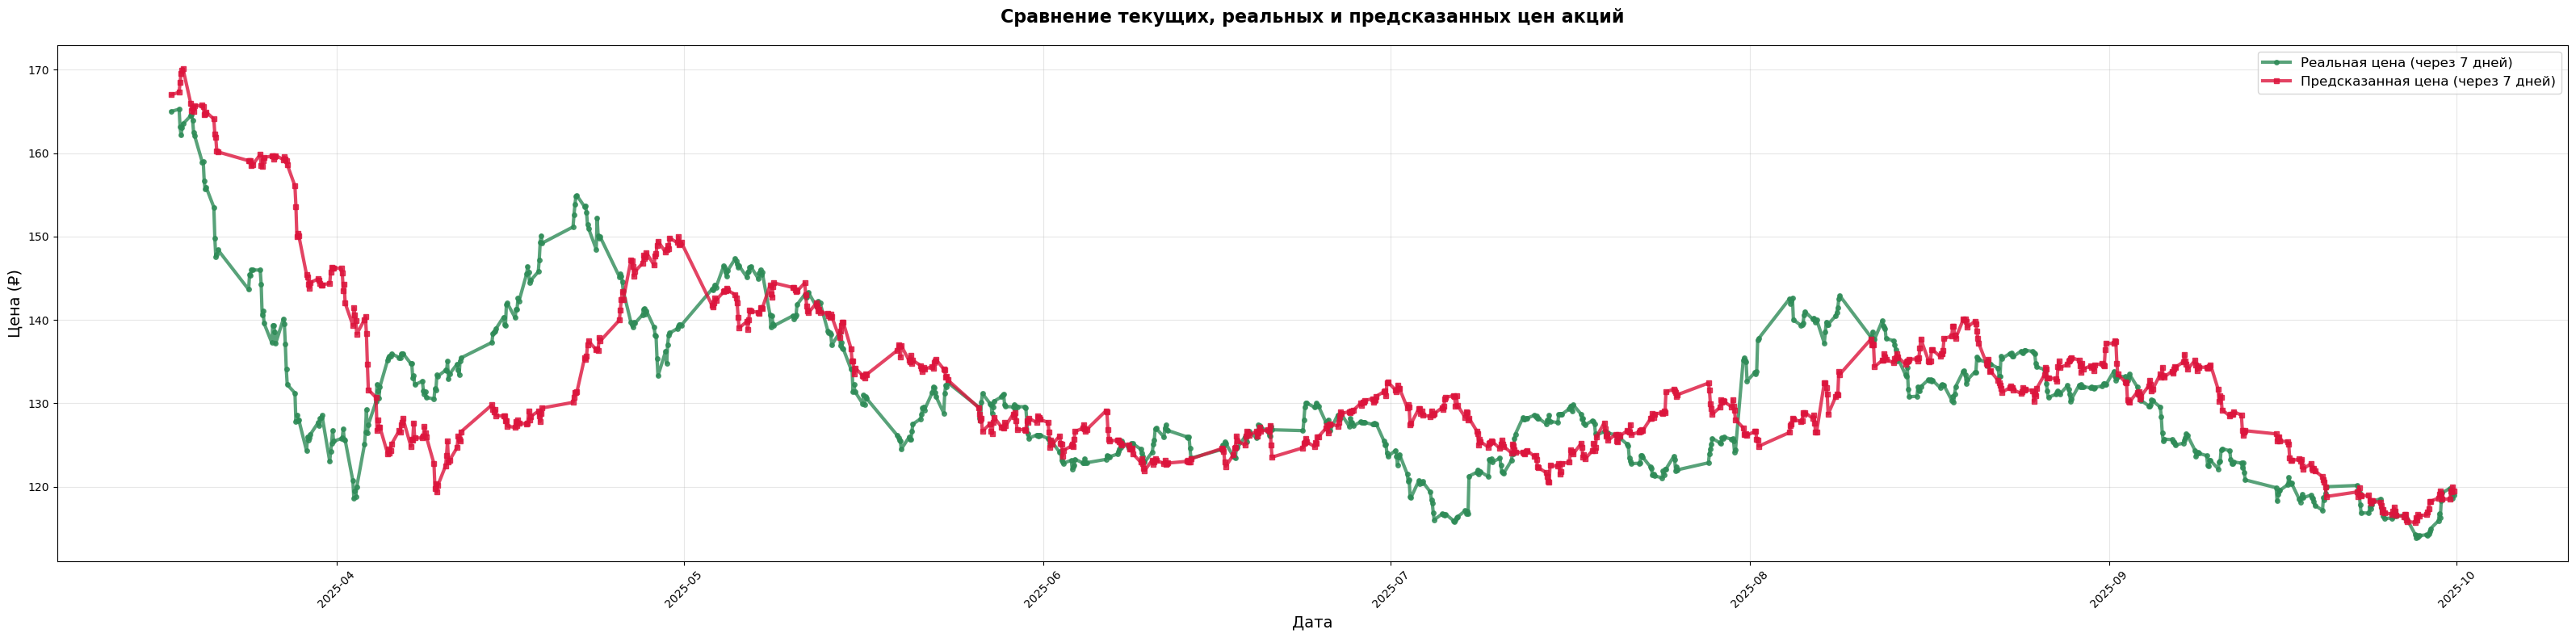

In [115]:
visualize_price_predictions(df_GAZP_pred)

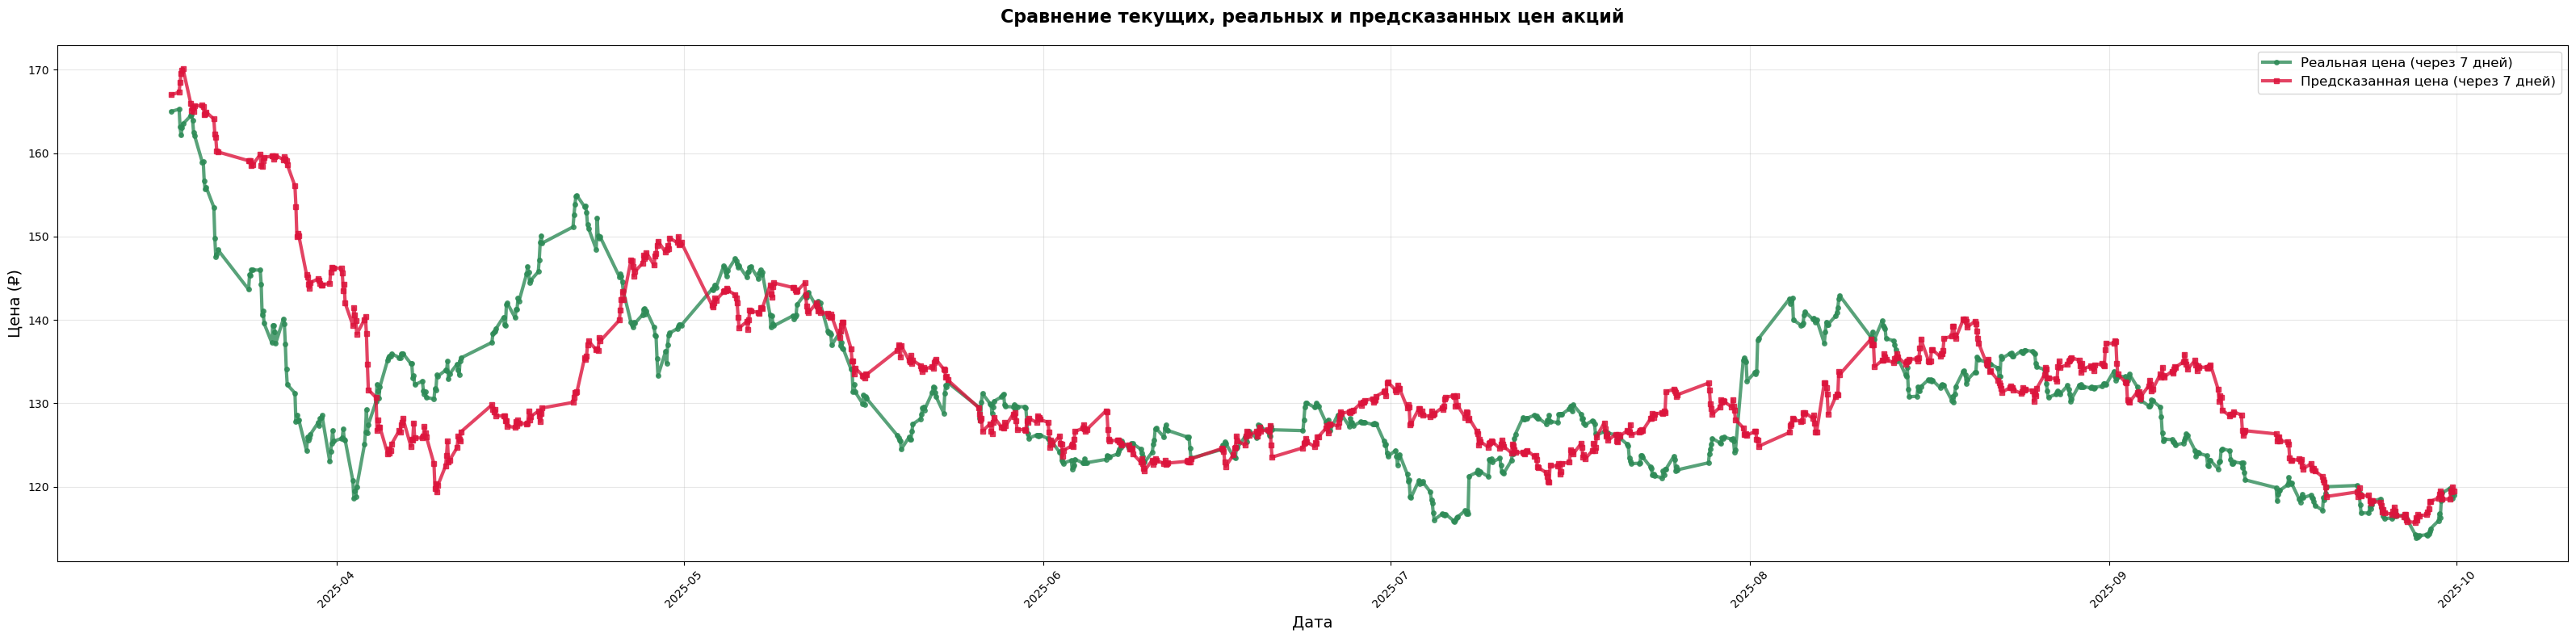

In [71]:
visualize_price_predictions(df_GAZP_pred)

In [159]:
def visualize_predictions_comparison_price(results_df):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame с колонками ['begin', 'target_price_change', 'predict']
    """
    # Конвертируем дату если нужно
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])

    results_df['target_price_change'] = results_df['close'] * (1 + results_df['target_price_change'] / 100)
    results_df['predict'] = results_df['close'] * (1 + results_df['predict'] / 100)

    # Сортируем по дате
    results_df = results_df.sort_values('begin')
    
    # Создаем один большой график
    plt.figure(figsize=(16, 8))
    
    # График реальных и предсказанных изменений
    plt.plot(results_df['begin'] + pd.Timedelta(days=0) , results_df['target_price_change'], 
             linewidth=3, color='#2E8B57', label='Реальное изменение', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=3, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=4, alpha=0.8)
    
    # Настройки графика
    plt.title('Сравнение реальных и предсказанных изменений цены', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Изменение цены (%)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Красивое оформление
    plt.tight_layout()
    plt.show()

In [157]:
def visualize_predictions_comparison(results_df):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame с колонками ['begin', 'target_price_change', 'predict']
    """
    # Конвертируем дату если нужно
    if results_df['begin'].dtype == 'object':
        results_df = results_df.copy()
        results_df['begin'] = pd.to_datetime(results_df['begin'])
    
    # Сортируем по дате
    results_df = results_df.sort_values('begin')
    
    # Создаем один большой график
    plt.figure(figsize=(16, 8))
    
    # График реальных и предсказанных изменений
    plt.plot(results_df['begin'] + pd.Timedelta(days=0), results_df['target_price_change'], 
             linewidth=3, color='#2E8B57', label='Реальное изменение', marker='o', markersize=4, alpha=0.8)
    plt.plot(results_df['begin'], results_df['predict'], 
             linewidth=3, color='#DC143C', label='Предсказанное изменение', marker='s', markersize=4, alpha=0.8)
    
    # Нулевая линия
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
    
    # Настройки графика
    plt.title('Сравнение реальных и предсказанных изменений цены', 
              fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Изменение цены (%)', fontsize=14)
    plt.xlabel('Дата', fontsize=14)
    plt.legend(fontsize=12, loc='best')
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    
    # Красивое оформление
    plt.tight_layout()
    plt.show()

In [6]:
def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")

In [8]:
def train_predict_rf(X_train, X_test, y_train):
    """Обучает и предсказывает Random Forest для регрессии"""
    param_grid = {
        'n_estimators': [150, 225, 350],
        'max_depth': [5, 8, 15],
        'min_samples_split': [5, 10, 15],
        'min_samples_leaf': [2, 4, 6]
    }
    
    model = RandomForestRegressor(random_state=13)
    #model.fit(X_train, y_train)
    #y_pred = model.predict(X_test)
    
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"Random Forest - лучшие параметры: {grid_search.best_params_}")
    y_pred = grid_search.predict(X_test)

    return y_pred

def train_predict_catboost(X_train, X_test, y_train):
    """Обучает и предсказывает CatBoost для регрессии"""
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'iterations': [150, 225, 350]
    }
    
    model = CatBoostRegressor(verbose=False, random_state=13)
    #model.fit(X_train, y_train)
    #y_pred = model.predict(X_test)
    
    grid_search = GridSearchCV(model, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print(f"CatBoost - лучшие параметры: {grid_search.best_params_}")
    y_pred = grid_search.predict(X_test)
    
    return y_pred

In [73]:
def train_predict_rf(X_train, X_test, y_train):
    """Обучает и предсказывает Random Forest для регрессии"""
    model = RandomForestRegressor(random_state=13)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred

def train_predict_catboost(X_train, X_test, y_train):
    """Обучает и предсказывает CatBoost для регрессии"""
    model = CatBoostRegressor(verbose=False, random_state=13)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return y_pred, model

In [12]:
def train_test_split_by_date(df, target_column, test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values('begin').reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df['begin'].min()} - {train_df['begin'].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df['begin'].min()} - {test_df['begin'].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=['begin', target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=['begin', target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

# 2 Подготовка данных

In [15]:
data_SBER = pd.read_csv("../../../data/stock_features_data/stocks_features_SBER.csv")

data_GAZP = pd.read_csv("../../../data/stock_features_data/stocks_features_GAZP.csv")

part_SBER = data_SBER[['begin', 'close', 'target_class']]
data_SBER.drop(['close', 'target_class'], axis=1, inplace=True)

part_GAZP = data_GAZP[['begin', 'close', 'target_class']]
data_GAZP.drop(['close', 'target_class'], axis=1, inplace=True)

X_train_SBER, X_test_SBER, y_train_SBER, y_test_SBER = train_test_split_by_date(
    df=data_SBER, 
    target_column='target_price_change',
    test_size=0.2
)

X_train_GAZP, X_test_GAZP, y_train_GAZP, y_test_GAZP = train_test_split_by_date(
    df=data_GAZP, 
    target_column='target_price_change',
    test_size=0.2
)

Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 83
Train: 2022-07-04 10:00:00 - 2025-03-17 16:00:00 (3342 samples)
Test:  2025-03-17 18:00:00 - 2025-09-30 18:00:00 (836 samples)
Признаков: 83


In [85]:
data_GAZP.head()

,begin,MA_20,MA_50,MA_90,MA_200,EMA_20,EMA_50,EMA_90,EMA_200,WMA_20,...,DISTANCE_MA_200,DISTANCE_EMA_20,DISTANCE_EMA_50,DISTANCE_EMA_90,DISTANCE_EMA_200,DISTANCE_WMA_20,DISTANCE_WMA_50,DISTANCE_WMA_90,DISTANCE_WMA_200,target_price_change
0,2022-07-04 10:00:00,245.2205,278.2834,292.999222,278.85940,231.852120,265.100933,278.110339,282.634642,220.896905,...,-0.348489,-0.216397,-0.314676,-0.346734,-0.357191,-0.177535,-0.302324,-0.351031,-0.365883,7.381110
1,2022-07-04 12:00:00,239.8470,275.7436,291.805556,278.62635,227.675728,262.076431,276.107397,281.548989,215.447333,...,-0.325261,-0.174264,-0.282652,-0.319106,-0.332265,-0.127397,-0.268103,-0.322874,-0.341747,1.606383
2,2022-07-04 14:00:00,234.2500,273.2148,290.589556,278.38780,223.859944,259.155311,274.140798,280.472953,210.472381,...,-0.326084,-0.161931,-0.276071,-0.315644,-0.331094,-0.108624,-0.259660,-0.318659,-0.341023,1.897553
3,2022-07-04 16:00:00,228.5720,270.6948,289.334444,278.14410,220.200902,256.263688,272.170159,279.386022,205.823810,...,-0.333295,-0.157860,-0.276370,-0.318662,-0.336259,-0.099035,-0.258146,-0.320839,-0.346522,2.593831
4,2022-07-04 18:00:00,223.0245,268.1802,288.092889,277.90455,216.967483,253.517300,270.261753,278.322368,201.793143,...,-0.329806,-0.141576,-0.265336,-0.310853,-0.330812,-0.077025,-0.244903,-0.312165,-0.341546,1.422819


In [89]:
y_test_GAZP.head()

3342   -5.166964
3343   -4.523397
3344   -5.911188
3345   -6.261201
3346   -5.948191
Name: target_price_change, dtype: float64

# 3 Обучение моделей с подбором гиперпараметров

## 3.1 Вот он, лес

### 3.1.1 Сбер

In [20]:
y_pred_SBER = train_predict_rf(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 3.1263%
RMSE: 4.1015%
R²: -1.1923
Accuracy направления: 0.4749


In [575]:
y_pred_SBER = train_predict_rf(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 2.4349%
RMSE: 2.9293%
R²: -0.1191
Accuracy направления: 0.5356


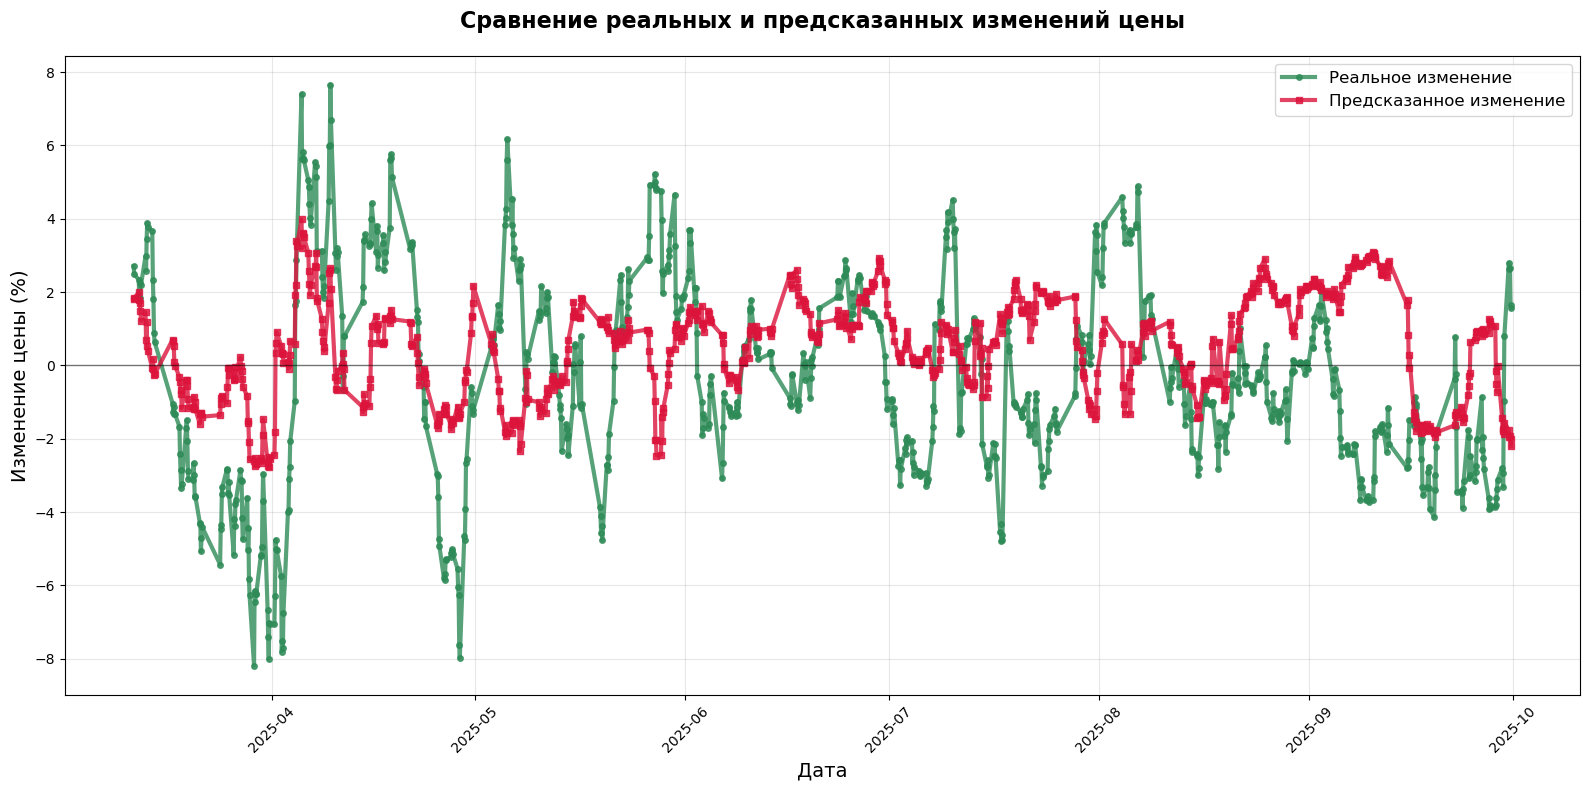

In [508]:
df_SBER_pred = pd.DataFrame(y_test_SBER)
df_SBER_pred = df_SBER_pred.merge(part_SBER[['begin', 'close']], left_index=True, right_index=True)
df_SBER_pred['predict'] = y_pred_SBER
visualize_predictions_comparison(df_SBER_pred)

### 3.1.2 Газпром

In [509]:
y_pred_GAZP = train_predict_rf(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 4.5330%
RMSE: 6.0501%
R²: -0.0356
Accuracy направления: 0.6604


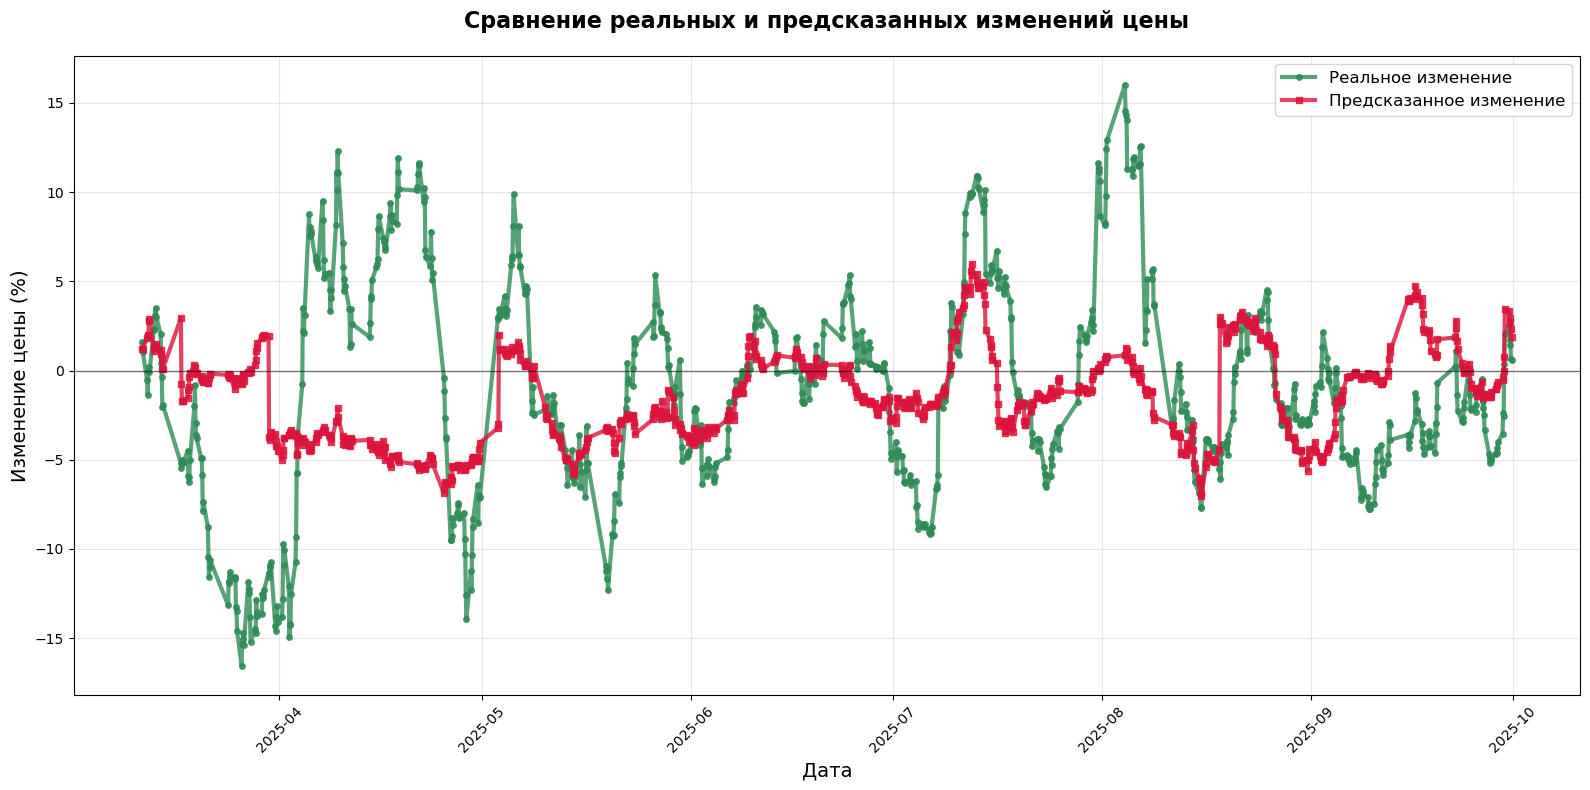

In [547]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
visualize_predictions_comparison(df_GAZP_pred)

## 3.2 Бустинг

### 3.2.1 Сбер

In [24]:
y_pred_SBER = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)

CatBoost - лучшие параметры: {'depth': 8, 'iterations': 150, 'l2_leaf_reg': 3, 'learning_rate': 0.01}

📊 МОДЕЛЬ: 
MAE: 2.3917%
RMSE: 2.9816%
R²: -0.1585
Accuracy направления: 0.4725


In [614]:
y_pred_SBER = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 2.6169%
RMSE: 3.2959%
R²: -0.4157
Accuracy направления: 0.3947


In [125]:
y_pred_SBER, _ = train_predict_catboost(X_train_SBER, X_test_SBER, y_train_SBER)
evaluate_regression(y_test_SBER, y_pred_SBER)


📊 МОДЕЛЬ: 
MAE: 2.6169%
RMSE: 3.2959%
R²: -0.4157
Accuracy направления: 0.3947


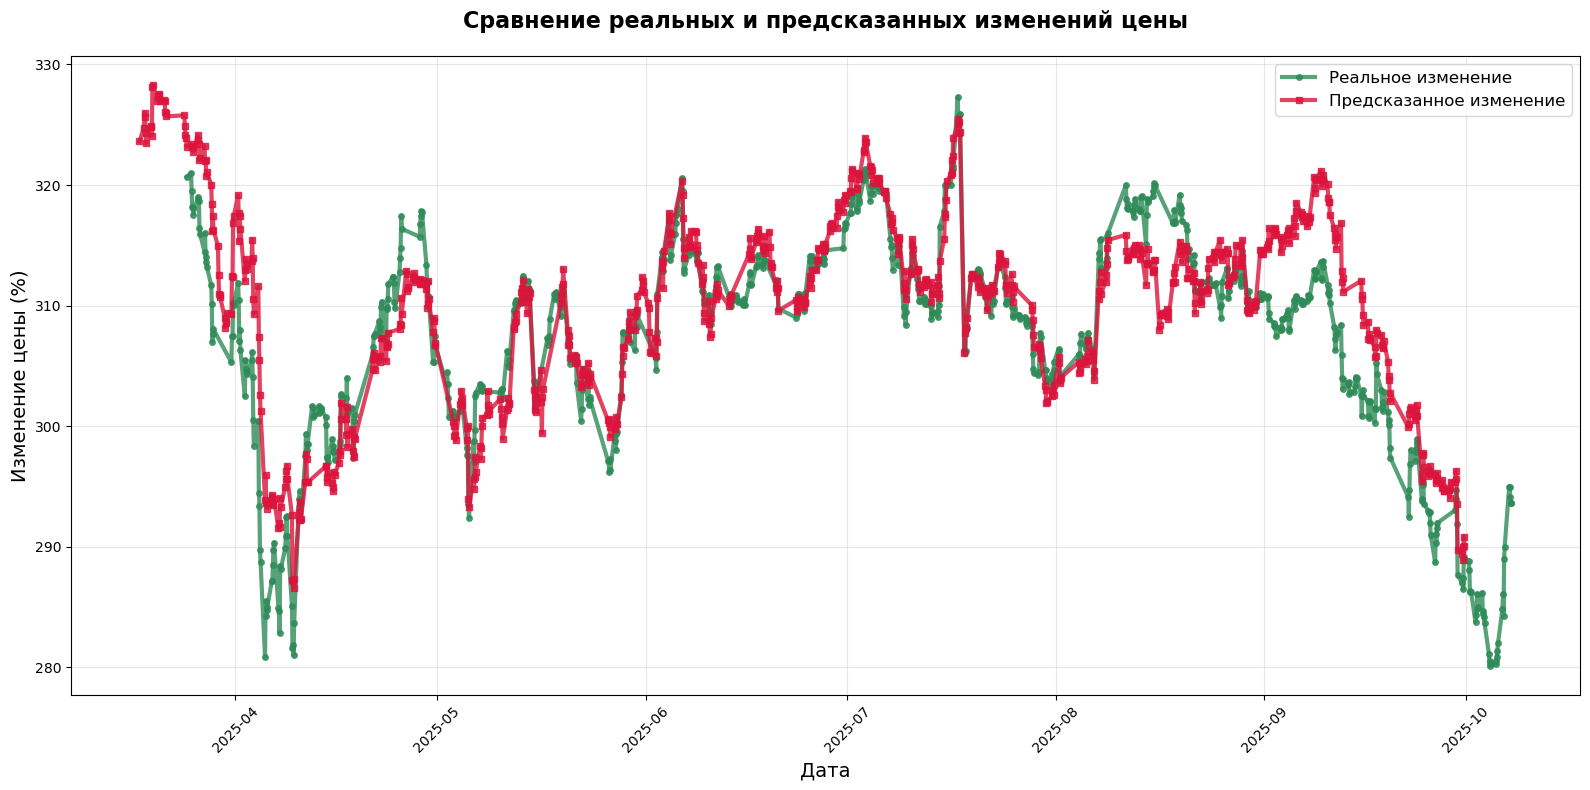

In [145]:
visualize_predictions_comparison_price(df_SBER_pred)

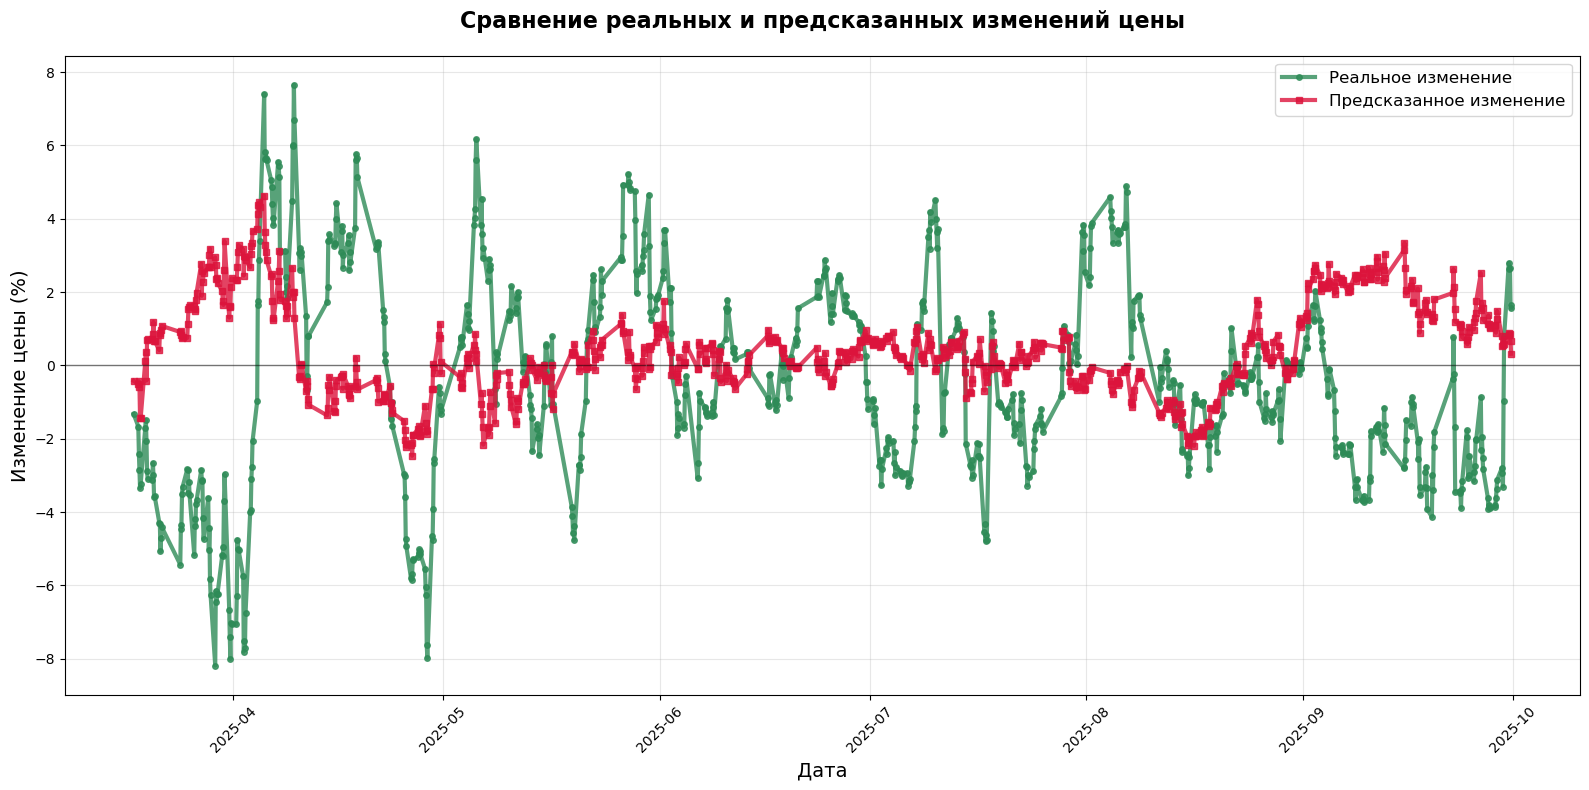

In [129]:
df_SBER_pred = pd.DataFrame(y_test_SBER)
df_SBER_pred = df_SBER_pred.merge(part_SBER[['begin', 'close']], left_index=True, right_index=True)
df_SBER_pred['predict'] = y_pred_SBER
visualize_predictions_comparison(df_SBER_pred)

### 3.2.2 Газпром

In [40]:
y_pred_GAZP = train_predict_catboost(X_train_GAZP.drop(['MA_90'], axis=1),
                               X_test_GAZP.drop(['MA_90'], axis=1),
                               y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 4.4937%
RMSE: 6.0267%
R²: -0.0084
Accuracy направления: 0.6734


In [36]:
y_pred_GAZP = train_predict_catboost(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 4.4728%
RMSE: 5.9113%
R²: 0.0298
Accuracy направления: 0.6376


In [75]:
y_pred_GAZP, model = train_predict_catboost(X_train_GAZP, X_test_GAZP, y_train_GAZP)
evaluate_regression(y_test_GAZP, y_pred_GAZP)


📊 МОДЕЛЬ: 
MAE: 4.4728%
RMSE: 5.9113%
R²: 0.0298
Accuracy направления: 0.6376


In [29]:
df_GAZP_pred

,target_price_change,begin,close,predict
3342,-5.166964,2025-03-17 18:00:00,173.99,-4.023906
3343,-4.523397,2025-03-18 10:00:00,173.10,-3.348286
3344,-5.911188,2025-03-18 12:00:00,173.40,-2.829952
3345,-6.261201,2025-03-18 14:00:00,172.97,-1.964605
3346,-5.948191,2025-03-18 16:00:00,173.33,-1.932278
...,...,...,...,...
4173,2.550496,2025-09-30 10:00:00,116.84,1.434933
4174,1.734399,2025-09-30 12:00:00,117.62,1.593511
4175,1.431737,2025-09-30 14:00:00,117.34,1.706891
4176,0.636402,2025-09-30 16:00:00,117.85,1.827343


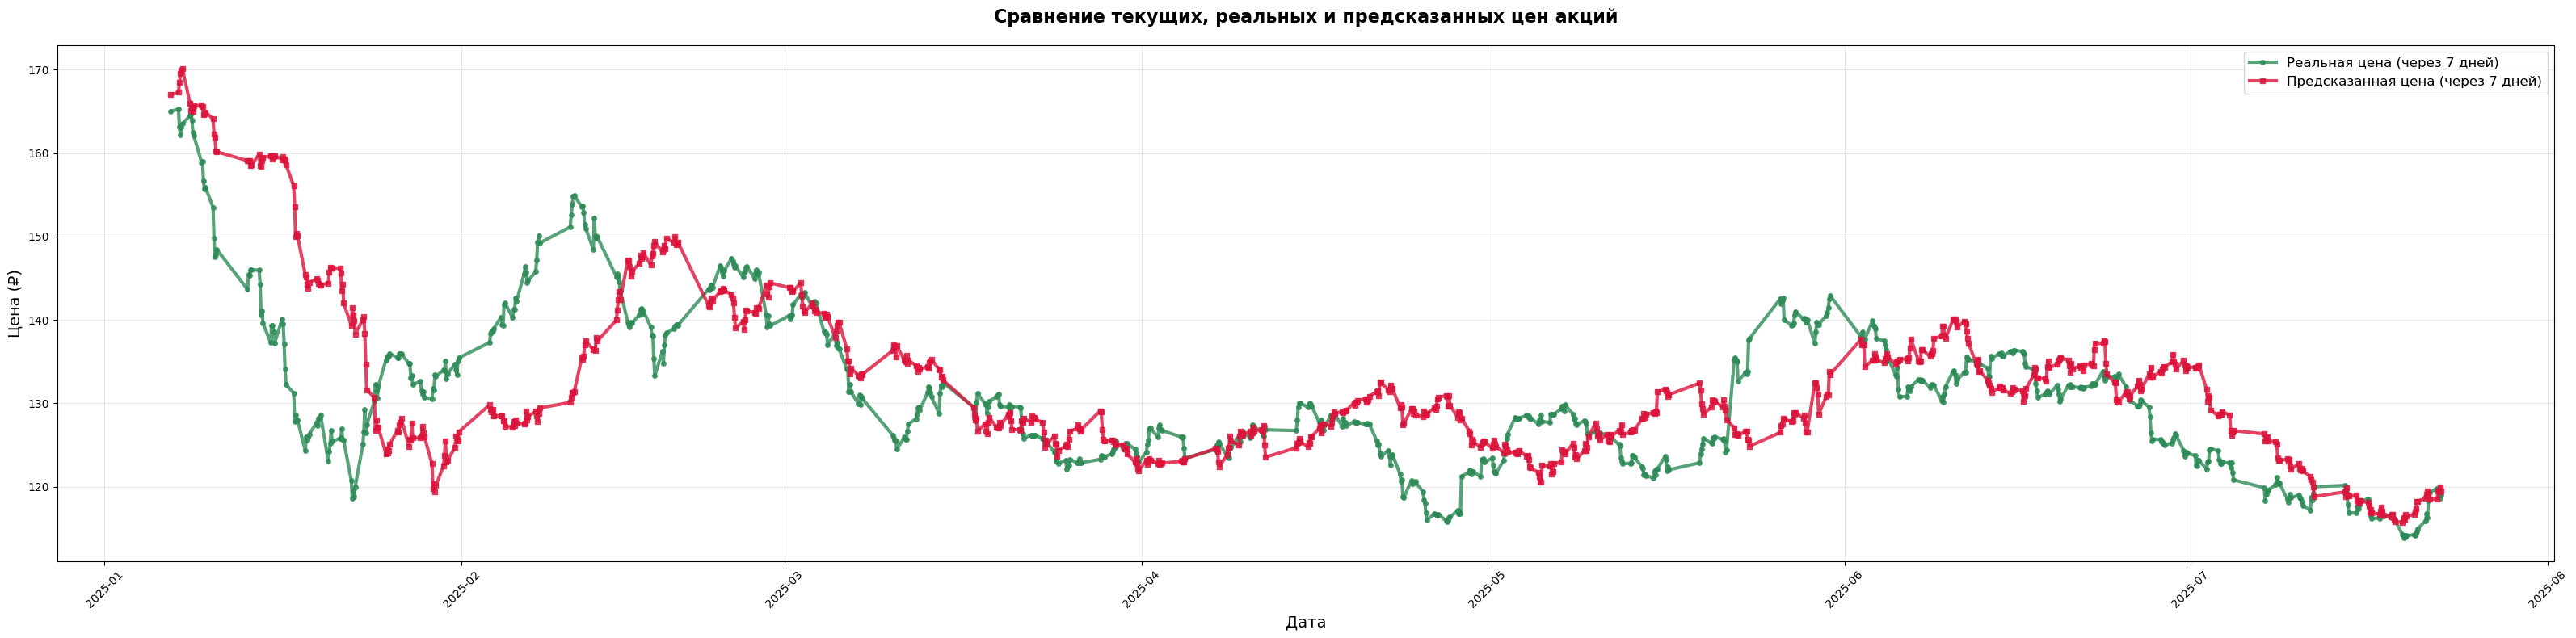

In [55]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
visualize_price_predictions(df_GAZP_pred)

In [93]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)

In [103]:
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)

In [109]:
df_GAZP_pred['predict'] = y_pred_GAZP

In [165]:
df_GAZP_pred[(df_GAZP_pred['begin'] > '2025-04-10') & (df_GAZP_pred['begin'] < '2025-04-21')]

,target_price_change,begin,close,predict
3448,7.124580,2025-04-10 10:00:00,125.06,-2.047117
3449,5.792635,2025-04-10 12:00:00,126.54,-2.175286
3450,4.479691,2025-04-10 14:00:00,129.25,-2.925529
3451,5.109143,2025-04-10 16:00:00,126.44,-2.767378
3452,4.755179,2025-04-10 18:00:00,127.44,-3.372543
3453,3.448011,2025-04-11 10:00:00,130.22,-4.232783
3454,1.307832,2025-04-11 12:00:00,132.28,-4.698694
3455,1.483454,2025-04-11 14:00:00,131.45,-4.423435
3456,3.422665,2025-04-11 16:00:00,130.60,-3.897228
3457,2.621411,2025-04-11 18:00:00,131.99,-4.091357


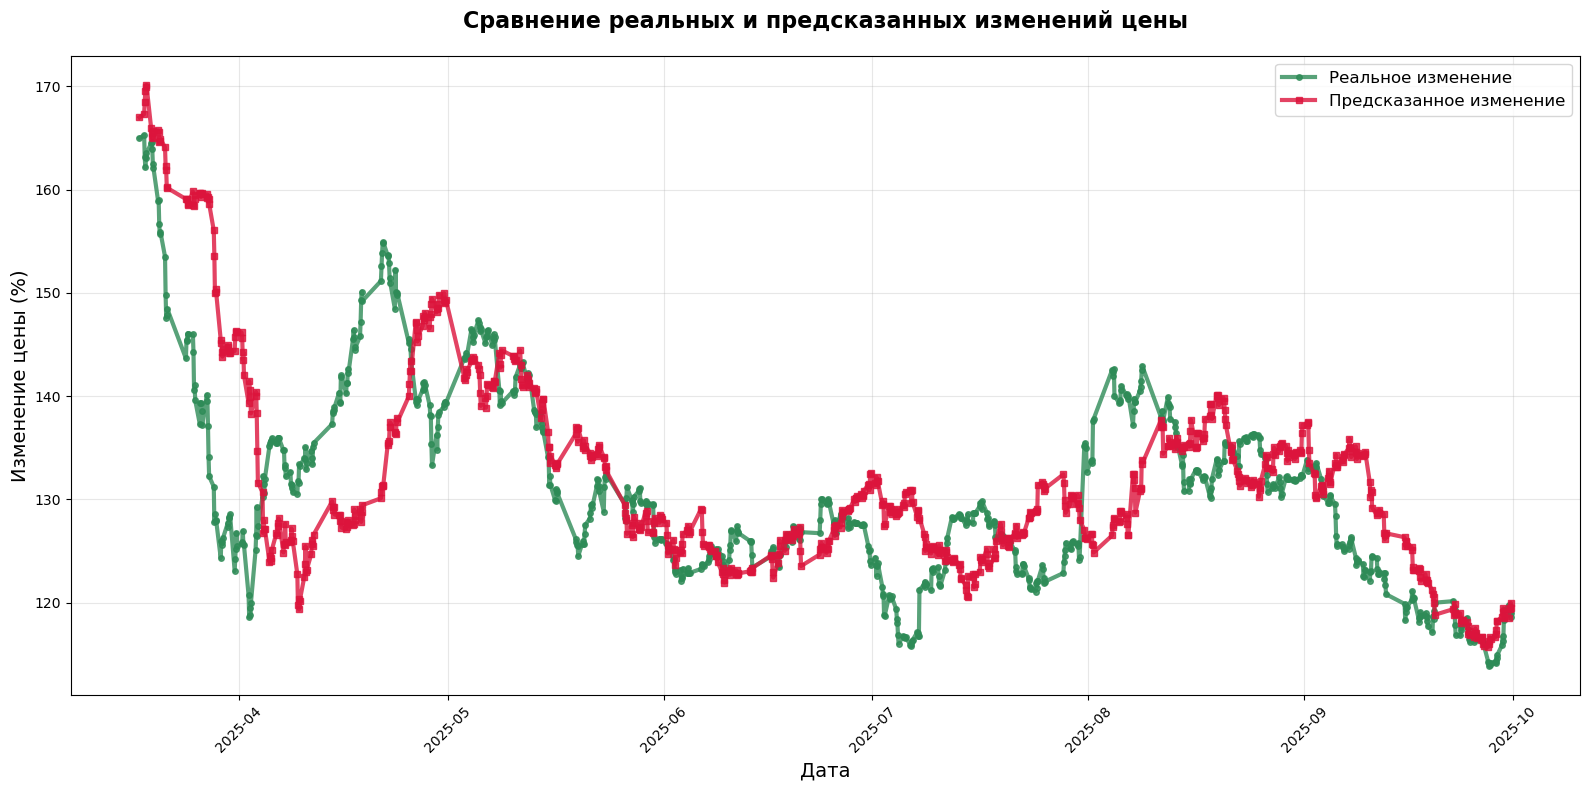

In [151]:
visualize_predictions_comparison_price(df_GAZP_pred)

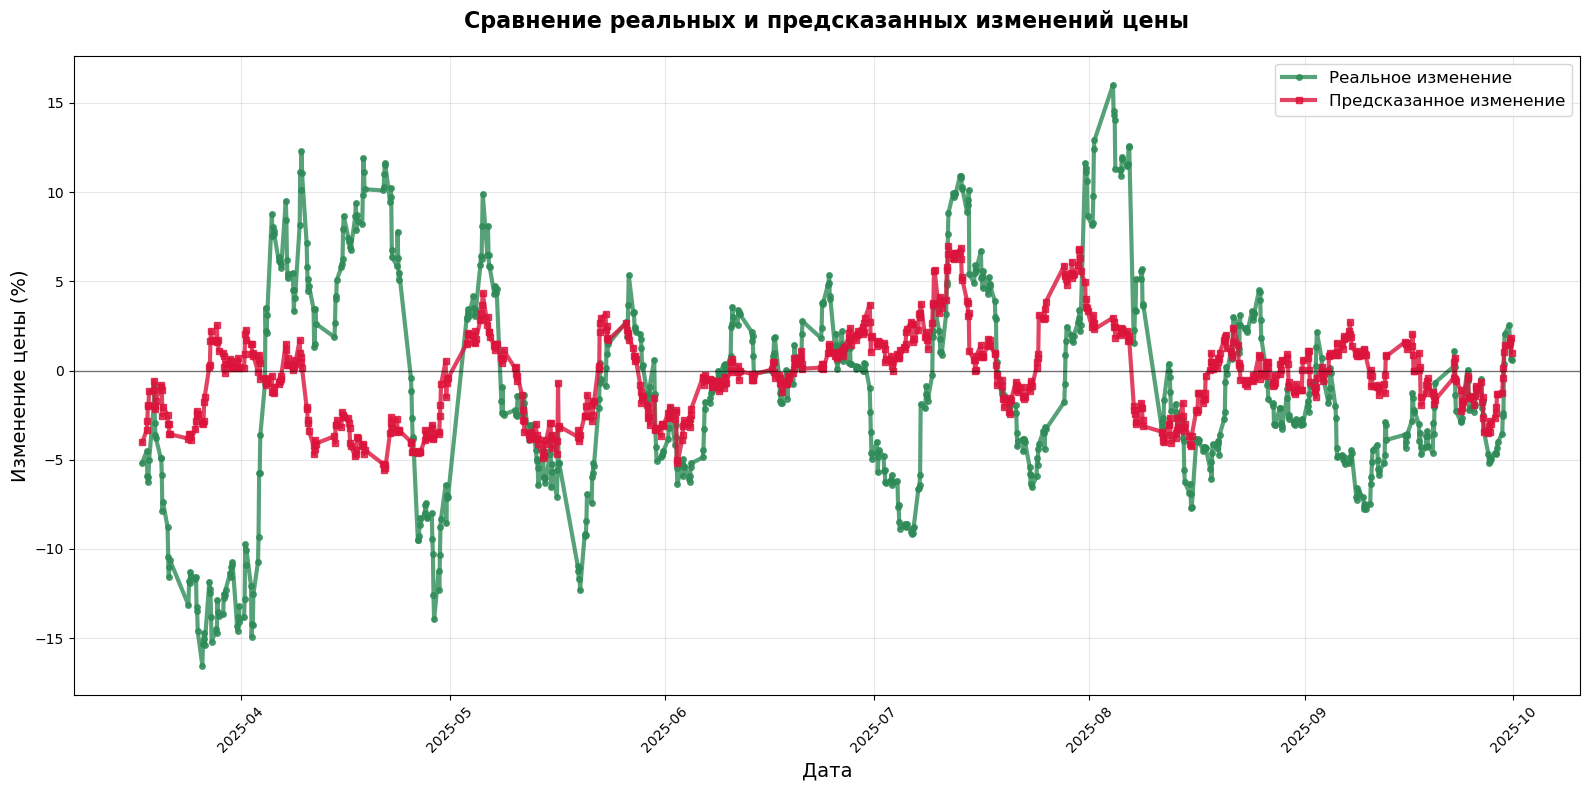

In [119]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
visualize_predictions_comparison(df_GAZP_pred)

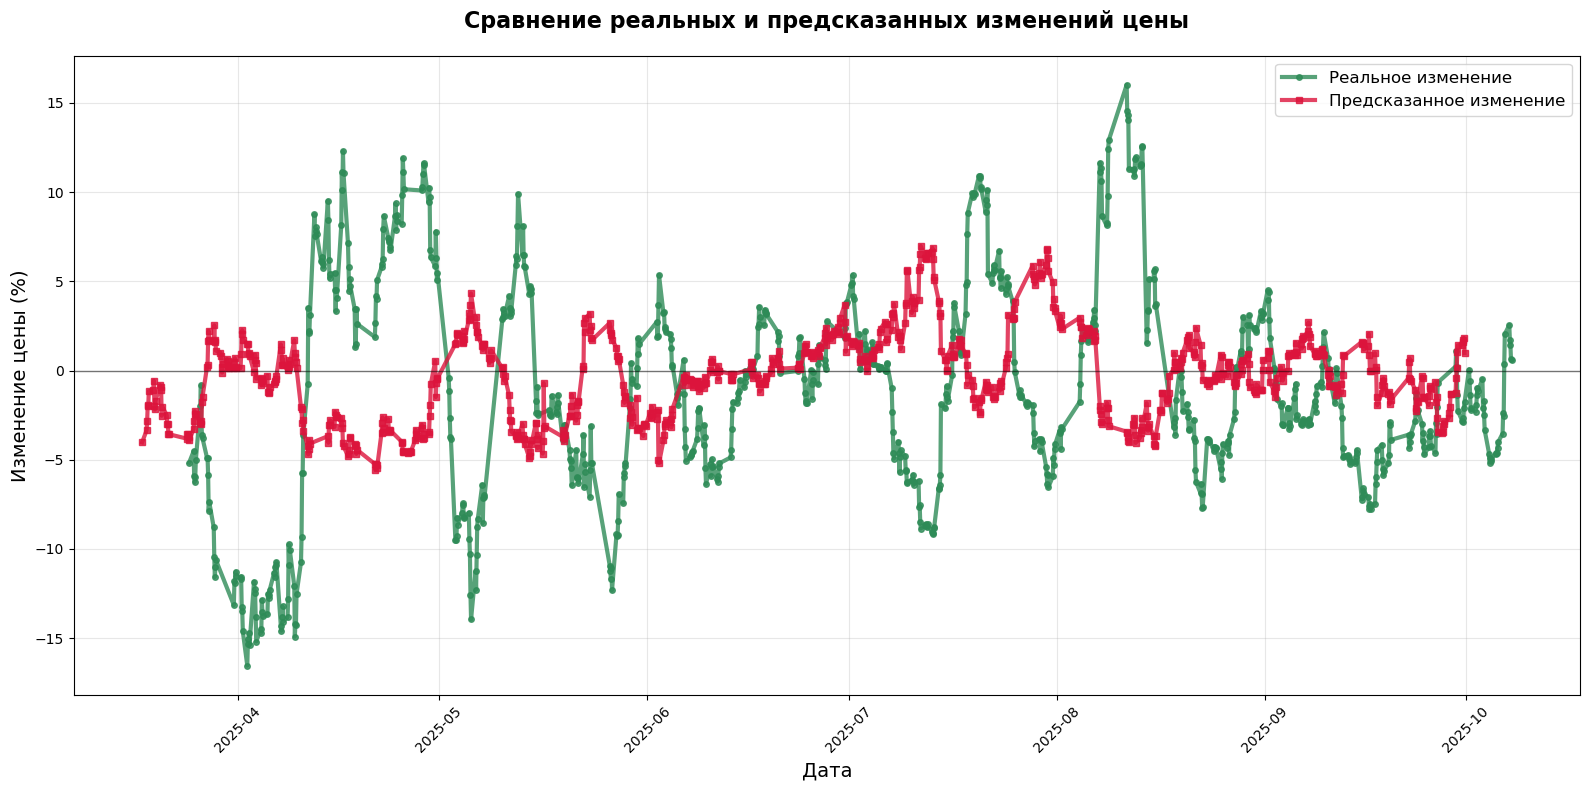

In [155]:
visualize_predictions_comparison(df_GAZP_pred)

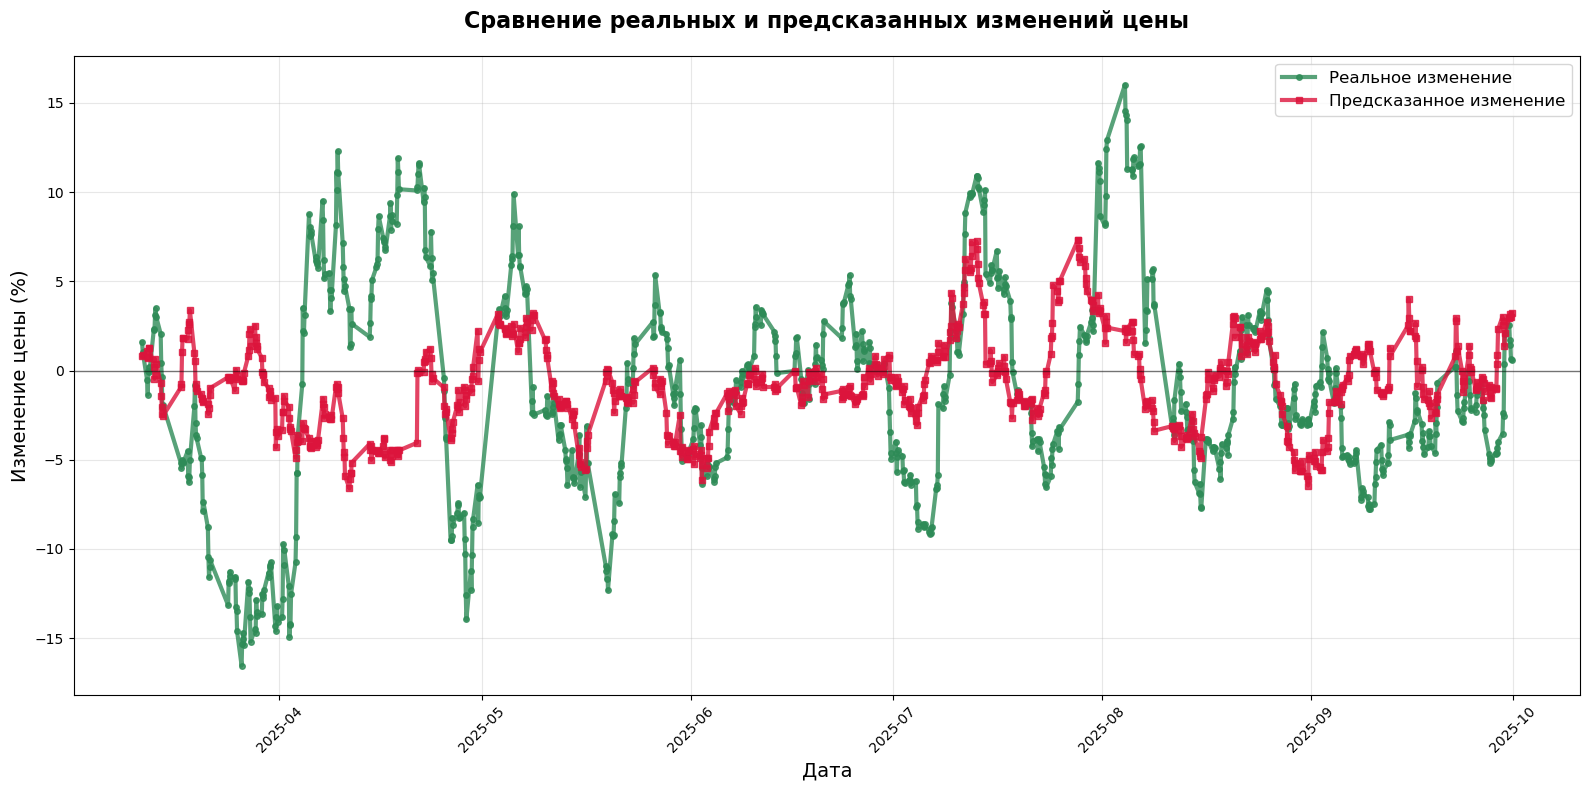

In [516]:
df_GAZP_pred = pd.DataFrame(y_test_GAZP)
df_GAZP_pred = df_GAZP_pred.merge(part_GAZP[['begin', 'close']], left_index=True, right_index=True)
df_GAZP_pred['predict'] = y_pred_GAZP
visualize_predictions_comparison(df_GAZP_pred)